Analyzing flight delays using weather data

This project analyzes the relationship between weather conditions and flight delays using a large flight dataset.

In [6]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Dataset Source

The dataset used in this project was obtained from a publicly available online flight delay dataset.
Source:
https://www.kaggle.com/datasets/threnjen/2019-airline-delays-and-cancellations

The original dataset contains over 6 million records. Due to its large size, it was uploaded to Google Drive and downloaded directly from a shared link. This allows the notebook to be run without manual downloads or file path modifications, ensuring that the results can be reproduced for all users.

In [7]:
file_id = "1YsNdOh6KN3rLtGRIA8dYFnwlRtvRlZsr"
url = f"https://drive.google.com/uc?id={file_id}"
df = pd.read_csv(url)

In [8]:
#Data information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 26 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   MONTH                          500000 non-null  int64  
 1   DAY_OF_WEEK                    500000 non-null  int64  
 2   DEP_DEL15                      500000 non-null  int64  
 3   DEP_TIME_BLK                   500000 non-null  object 
 4   DISTANCE_GROUP                 500000 non-null  int64  
 5   SEGMENT_NUMBER                 500000 non-null  int64  
 6   CONCURRENT_FLIGHTS             500000 non-null  int64  
 7   NUMBER_OF_SEATS                500000 non-null  int64  
 8   CARRIER_NAME                   500000 non-null  object 
 9   AIRPORT_FLIGHTS_MONTH          500000 non-null  int64  
 10  AIRLINE_FLIGHTS_MONTH          500000 non-null  int64  
 11  AIRLINE_AIRPORT_FLIGHTS_MONTH  500000 non-null  int64  
 12  AVG_MONTHLY_PASS_AIRPORT      

Dataset Information

The original dataset contained 6,489,062 rows and 26 columns. Due to its large size (approximately 1.3 GB), a subset of 500,000 rows was extracted and uploaded to Google Drive to improve accessibility and processing efficiency.

The dataset used (500,000 rows) comprises 26 columns covering various characteristics of flight operations and weather. Numeric data, such as temperature, wind speed, precipitation, and snowfall, are stored as integer and decimal values, while categorical information, such as airport name and time period, is stored as text values. The memory used for this subset is approximately 99.2 MB.

In [9]:
df = df[[
    "MONTH",
    "DAY_OF_WEEK",
    "DEP_DEL15",
    "DEP_TIME_BLK",
    "DISTANCE_GROUP",
    "SEGMENT_NUMBER",
    "CONCURRENT_FLIGHTS",
    "CARRIER_NAME",
    "PLANE_AGE",
    "DEPARTING_AIRPORT",
    "PRCP",
    "SNOW",
    "SNWD",
    "TMAX",
    "AWND"
]]

Removal of Unnecessary Columns

Some columns were removed because they were not directly related to the impact of weather conditions on flight delays.

In [10]:
df.dropna(inplace=True)

Handling Missing Values

Missing values were removed to improve data quality.

In [11]:
df.drop_duplicates(inplace=True)

Removing Duplicate Rows

Duplicate rows were removed to avoid repeating information in the analysis.

In [12]:
df = df.sample(n=25000, random_state=42)

Sampling the Dataset

The original dataset was first reduced to a subset of 500,000 rows and then uploaded to Google Drive for easier access. Subsequently, a random sample of 25,000 rows was selected from this subset to expedite and improve the efficiency of the analysis.


In [13]:
df.describe()

,MONTH,DAY_OF_WEEK,DEP_DEL15,DISTANCE_GROUP,SEGMENT_NUMBER,CONCURRENT_FLIGHTS,PLANE_AGE,PRCP,SNOW,SNWD,TMAX,AWND
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,6.617840,3.916280,0.189560,3.824240,3.046840,27.733480,11.458600,0.104361,0.032776,0.086512,71.394228,8.366052
std,3.403471,1.989409,0.391961,2.387848,1.760741,21.395427,6.941347,0.354111,0.329889,0.704143,18.375168,3.628573
min,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,-10.000000,0.000000
25%,4.000000,2.000000,0.000000,2.000000,2.000000,11.000000,5.000000,0.000000,0.000000,0.000000,59.000000,5.820000
50%,7.000000,4.000000,0.000000,3.000000,3.000000,22.000000,12.000000,0.000000,0.000000,0.000000,74.000000,7.830000
75%,10.000000,6.000000,0.000000,5.000000,4.000000,38.000000,17.000000,0.020000,0.000000,0.000000,86.000000,10.510000
max,12.000000,7.000000,1.000000,11.000000,14.000000,109.000000,32.000000,11.630000,17.200000,20.100000,115.000000,32.440000


How do we interpret the statistical measures mentioned above?

Let's analyze these statistical measures to understand the distribution of flight delays and weather conditions in the dataset:

count (25,000):
This indicates that the dataset contains 25,000 flight records after preprocessing and sampling. This is a sufficient number of observations for meaningful analysis and modeling.

Mean:
The mean provides the overall average for each characteristic. For example, the mean delay index (DEP_DEL15 ≈ 0.189560) indicates that approximately 19% of flights experienced delays of more than 15 minutes, while the majority of flights were on time.

The mean temperature (TMAX ≈ 71.3) shows that most flights took place in moderate weather conditions.

Standard Deviation:
The standard deviation measures how much the values vary around the mean. For example, a large variability in the number of simultaneous flights and weather variables indicates that the dataset encompasses a range of operational and atmospheric conditions, from low to high traffic and from calm to severe weather.

Minimum values:
Minimum values represent the lowest recorded values. For example, a minimum temperature of -10°C indicates that some flights took place in extremely cold weather conditions, while zero values for precipitation and snow indicate normal weather conditions.

25%:
This means that 25% of the data fall below these values. For example, 25% of flights experienced low traffic levels and minimal weather impact, indicating generally stable conditions for a large portion of the flights.

Medium (50%):
The median represents the middle value of the dataset. It is often more accurate than the mean. For example, a median delay index of zero confirms that more than half of the flights were not delayed.

75%:
This indicates that 75% of observations fall below these values. This helps to understand the upper range of normal operating and weather conditions.

Extreme Values:
Extreme values highlight extreme weather conditions in the dataset. For example, heavy rainfall (11.63) and high wind speed (32.4) indicate that the dataset includes rare but significant weather events that may contribute to flight delays.

General Interpretation:
The dataset shows a realistic mix of normal and extreme flight and weather conditions. Most flights arrive on time, but weather variables, such as rain, snow, and wind speed, are expected to play a significant role in explaining delay behavior.

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25000 entries, 239691 to 128050
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   MONTH               25000 non-null  int64  
 1   DAY_OF_WEEK         25000 non-null  int64  
 2   DEP_DEL15           25000 non-null  int64  
 3   DEP_TIME_BLK        25000 non-null  object 
 4   DISTANCE_GROUP      25000 non-null  int64  
 5   SEGMENT_NUMBER      25000 non-null  int64  
 6   CONCURRENT_FLIGHTS  25000 non-null  int64  
 7   CARRIER_NAME        25000 non-null  object 
 8   PLANE_AGE           25000 non-null  int64  
 9   DEPARTING_AIRPORT   25000 non-null  object 
 10  PRCP                25000 non-null  float64
 11  SNOW                25000 non-null  float64
 12  SNWD                25000 non-null  float64
 13  TMAX                25000 non-null  float64
 14  AWND                25000 non-null  float64
dtypes: float64(5), int64(7), object(3)
memory usage: 3.1

All variables have data types suitable for analysis. Numerical data are stored correctly as integers and decimals, while categorical data, such as airport names and time periods, are stored as text. This makes the dataset suitable for further preprocessing and analysis.

In [15]:
df.isnull().sum()

,0
MONTH,0
DAY_OF_WEEK,0
DEP_DEL15,0
DEP_TIME_BLK,0
DISTANCE_GROUP,0
SEGMENT_NUMBER,0
CONCURRENT_FLIGHTS,0
CARRIER_NAME,0
PLANE_AGE,0
DEPARTING_AIRPORT,0


No missing values were found after preprocessing, which improves data reliability.

In [16]:
df.duplicated().sum()

np.int64(0)

Duplicate rows were removed to avoid bias in the analysis.

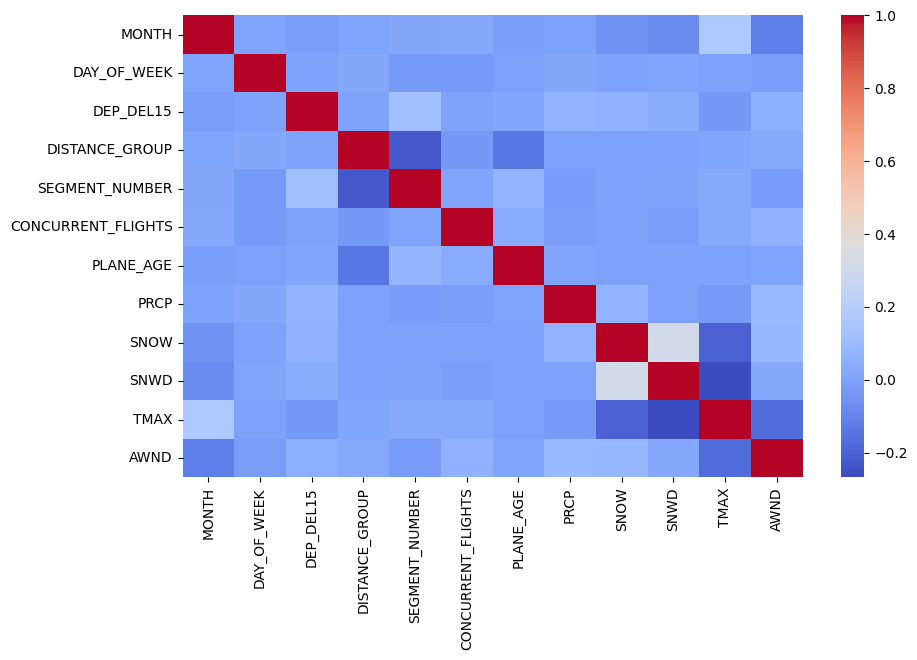

In [17]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap="coolwarm")
plt.show()

Correlation analysis helps identify relationships between weather variables and flight delay patterns.

In [18]:
df["DEP_DEL15"].value_counts()

,count
DEP_DEL15,
0,20261
1,4739


Flight Delay Distribution (DEP_DEL15)

The target variable DEP_DEL15 represents whether a flight was delayed by more than 15 minutes (1 = delayed, 0 = not delayed).

Results:

- 20,261 flights were not delayed (approximately 81.0%).
-4,739 flights were delayed (approximately 19.0%).

This indicates an imbalance in the dataset, as the majority of flights arrive on time, while a smaller percentage are delayed.

This imbalance is important for future analysis and modeling, as it may affect the performance of prediction models and should be considered during model development.

In [19]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

outliers = ((numeric_df < (Q1 - 1.5 * IQR)) | (numeric_df > (Q3 + 1.5 * IQR))).sum()

outliers

,0
MONTH,0
DAY_OF_WEEK,0
DEP_DEL15,4739
DISTANCE_GROUP,1280
SEGMENT_NUMBER,388
CONCURRENT_FLIGHTS,778
PLANE_AGE,0
PRCP,5241
SNOW,627
SNWD,624


Detecting Outliers Using the Interquartile Range Method

This step identifies the number of outliers (outliers) in each numerical property using the Interquartile Range (IQR) method. Outliers are values ​​that fall significantly outside the normal distribution of the data.

Results:

- Several properties, such as PRCP, SNOW, SNWD, and AWND, contain a significant number of outliers, which is expected given the wide variation in weather conditions and the likelihood of extreme weather events.

- The CONCURRENT_FLIGHTS and DISTANCE_GROUP properties also show some outliers, indicating variations in air traffic at airports and flight distances.

- Basic calendar properties, such as MONTH and DAY_OF_WEEK, show no outliers or very few, which is expected given their consistent ranges.

The presence of outliers in the PLANE_AGE and TMAX properties indicates variations in aircraft age and temperature conditions across different flights.

Overall, the dataset contains a reasonable number of outliers, particularly in weather-related variables. These outliers are significant because they may represent real-world weather events that directly impact flight delays and should therefore only be discarded after careful consideration.

Experimentation and Visualization


Histogram

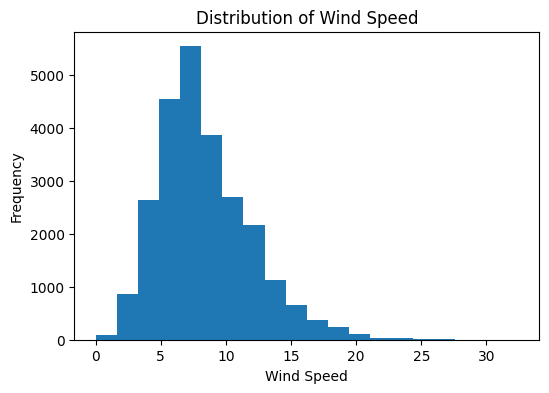

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(df['AWND'], bins=20)
plt.title('Distribution of Wind Speed')
plt.xlabel('Wind Speed')
plt.ylabel('Frequency')
plt.show()

The histogram shows the distribution of wind speed values in the dataset. Most flights were operated under moderate wind conditions, while extremely high wind speeds occurred less frequently.

Boxplot

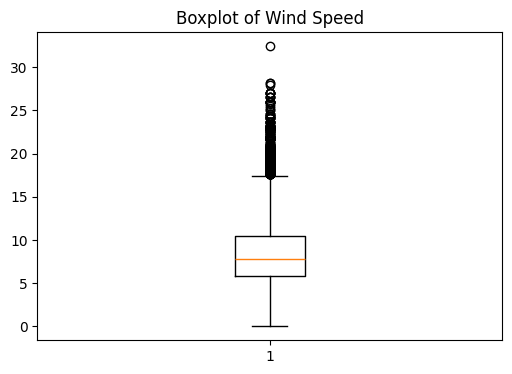

In [21]:
plt.figure(figsize=(6,4))
plt.boxplot(df['AWND'])
plt.title('Boxplot of Wind Speed')
plt.show()

The boxplot highlights the spread of wind speed values and identifies potential outliers. Some flights experienced unusually high wind speeds compared to the majority of observations.

Scatter Plot

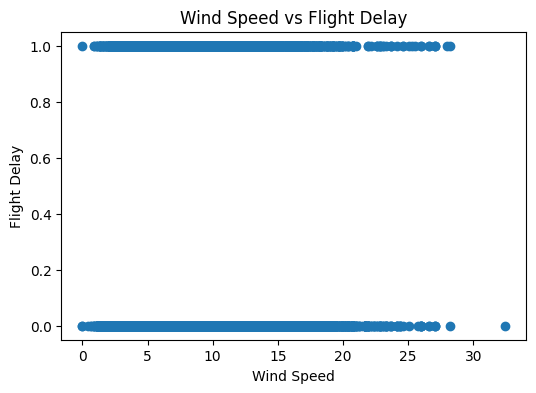

In [22]:
plt.figure(figsize=(6,4))
plt.scatter(df['AWND'], df['DEP_DEL15'])
plt.xlabel('Wind Speed')
plt.ylabel('Flight Delay')
plt.title('Wind Speed vs Flight Delay')
plt.show()

The scatter plot illustrates the relationship between wind speed and flight delays. Flights operating under stronger wind conditions appear more likely to experience delays.

Prediction

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

X = df[['AWND','PRCP','TMAX','PLANE_AGE','CONCURRENT_FLIGHTS']]
y = df['DEP_DEL15']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, predictions))

Accuracy: 0.694


Prediction Explanation

A Decision Tree classifier was used to predict whether a flight would be delayed based on weather and operational factors. The model was trained using wind speed, precipitation, temperature, aircraft age, and concurrent flights. The resulting accuracy demonstrates the effectiveness of these variables in predicting flight delays.

Conclusion

The experimental results indicate that weather and operational factors influence flight delays. Wind speed and precipitation showed noticeable effects on delay occurrence. Furthermore, the prediction model achieved reasonable accuracy, demonstrating the usefulness of machine learning techniques in forecasting flight delays.